In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat
import pickle

probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y
probe_position['chan_map'] = probe_data['chanMap0ind'].astype(int)

chan_map = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
merged = chan_map.merge(probe_position, left_on='probeloc', right_on='chan_map')\
                 .iloc[chan_map.index]\
                 .reset_index(drop=True)

probe = Probe()
probe.set_contacts(positions=merged.iloc[:, 2:4])
probe.set_device_channel_indices(range(256))


In [ ]:
recording_raw = se.read_intan(f"/home/ubuntu/Documents/jct/project/251205/M190011_260107_125346_merged_130.rhd", stream_id= '0', ignore_integrity_checks=True)

print('read success')

recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)

recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

#rec_corrected, motion = spre.correct_motion(recording=recording_f, preset="dredge_fast", output_motion=True, n_jobs = 30)
#recording_preprocessed = recording_f.save(format="binary", n_jobs = 30)


read success


In [3]:
import spikeinterface as si
import numpy as np
from spikeinterface.core import get_template_extremum_channel
import scipy.spatial.distance
from scipy.sparse.csgraph import connected_components
import pickle
import pandas as pd

output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
sorting_curated_phy = se.read_phy(f"{output_dir}/phy_folder_for_kilosort", exclude_cluster_groups=["noise"])
analyzer_curated_phy = si.create_sorting_analyzer(
    sorting=sorting_curated_phy, 
    recording=recording_f, 
    format='binary_folder',
    folder=output_dir + '/analyzer_curated',
    n_jobs=20
)

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "random_spikes": {"method": "all"},
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_curated_phy.compute(extensions_to_compute, extension_params=extension_params, n_jobs=25)

templates_ext = analyzer_curated_phy.get_extension("templates")
templates_dense = templates_ext.data["average"]
sparsity = analyzer_curated_phy.sparsity
unit_locations_ext = analyzer_curated_phy.get_extension("unit_locations")
unit_locations = unit_locations_ext.get_data()
channel_locations = analyzer_curated_phy.get_channel_locations()

if unit_locations.shape[1] >= 2:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations[:, :2], 
        unit_locations[:, :2], 
        metric="euclidean"
    )
else:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations, 
        unit_locations, 
        metric="euclidean"
    )

template_similarity_ext = analyzer_curated_phy.get_extension("template_similarity")
template_similarity = template_similarity_ext.get_data()

distance_threshold = 10.0
similarity_threshold = 0.95
num_units = len(analyzer_curated_phy.unit_ids)
pair_mask = np.zeros((num_units, num_units), dtype=bool)

for i in range(num_units):
    for j in range(i + 1, num_units):
        if unit_distances[i, j] < distance_threshold and template_similarity[i, j] > similarity_threshold:
            pair_mask[i, j] = True
            pair_mask[j, i] = True

n_components, labels = connected_components(
    csgraph=pair_mask, 
    directed=False, 
    return_labels=True
)

merge_unit_groups = []
unit_ids_list = analyzer_curated_phy.unit_ids
for component_id in range(n_components):
    unit_indices = np.where(labels == component_id)[0]
    if len(unit_indices) > 1:
        group = [unit_ids_list[i] for i in unit_indices]
        merge_unit_groups.append(group)

if len(merge_unit_groups) > 0:
    analyzer_merged = analyzer_curated_phy.merge_units(
        merge_unit_groups=merge_unit_groups,
        censor_ms=0.3,
        merging_mode="hard",
        new_id_strategy="append",
        format='binary_folder',
        folder=output_dir + '/analyzer_merged',
        verbose=True,
        n_jobs=20
    )
    
    analyzer_merged.compute(extensions_to_compute, extension_params=extension_params, n_jobs=30)
    
    templates_ext_merged = analyzer_merged.get_extension("templates")
    templates_dense_merged = templates_ext_merged.data["average"]
    sparsity_merged = analyzer_merged.sparsity
    unit_locations_ext_merged = analyzer_merged.get_extension("unit_locations")
    unit_locations_merged = unit_locations_ext_merged.get_data()
    channel_locations_merged = analyzer_merged.get_channel_locations()
    
    position_waveforms_merged = []
    unit_ids_list_merged = analyzer_merged.unit_ids
    
    for unit_id in unit_ids_list_merged:
        unit_index = analyzer_merged.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense_merged[unit_index, :, :]
        template_sparse_unit = sparsity_merged.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity_merged.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense_merged.shape[1], dtype=templates_dense_merged.dtype)
            position_waveforms_merged.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations_merged[sparse_channel_indices, :2]
        unit_location = unit_locations_merged[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms_merged.append(position_waveform)
    
    position_waveforms_merged = np.array(position_waveforms_merged)
    
    extremum_channels_merged = get_template_extremum_channel(
        analyzer_merged, 
        peak_sign="both",
        outputs="id"
    )
    
    neuron_inf = {}
    for idx, unit_id in enumerate(unit_ids_list_merged):
        neuron_inf[unit_id] = {
            'location_x': float(unit_locations_merged[idx, 0]),
            'location_y': float(unit_locations_merged[idx, 1]),
            'position_waveform': position_waveforms_merged[idx],
            'extremum_channel': extremum_channels_merged[unit_id]
        }
    
    sorting_final = analyzer_merged.sorting
    extremum_channels_final = extremum_channels_merged
else:
    position_waveforms = []
    for unit_id in unit_ids_list:
        unit_index = analyzer_curated_phy.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense[unit_index, :, :]
        template_sparse_unit = sparsity.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense.shape[1], dtype=templates_dense.dtype)
            position_waveforms.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations[sparse_channel_indices, :2]
        unit_location = unit_locations[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms.append(position_waveform)
    
    position_waveforms = np.array(position_waveforms)
    
    extremum_channels = get_template_extremum_channel(
        analyzer_curated_phy, 
        peak_sign="neg",
        outputs="id"
    )
    
    neuron_inf = {}
    for idx, unit_id in enumerate(unit_ids_list):
        neuron_inf[unit_id] = {
            'location_x': float(unit_locations[idx, 0]),
            'location_y': float(unit_locations[idx, 1]),
            'position_waveform': position_waveforms[idx],
            'extremum_channel': extremum_channels[unit_id]
        }
    
    sorting_final = analyzer_curated_phy.sorting
    extremum_channels_final = extremum_channels

spike_vector = sorting_final.to_spike_vector()

gt_detect_data = []
for spike in spike_vector:
    unit_index = spike['unit_index']
    unit_id = sorting_final.unit_ids[unit_index]
    sample_index = spike['sample_index']
    
    extremum_channel = extremum_channels_final[unit_id]
    
    gt_detect_data.append({
        'sample_index': sample_index,
        'unit_id': unit_id,
        'extremum_channel': str(extremum_channel)
    })

gt_detect_array = pd.DataFrame(gt_detect_data)

with open(output_dir + '/neuron_inf.pickle', 'wb') as f:
    pickle.dump(neuron_inf, f)

gt_detect_array.to_csv(output_dir + '/gt_detect_array.csv', index=False)

print(f"neuron_inf已保存到: {output_dir + '/neuron_inf.pickle'}")
print(f"包含 {len(neuron_inf)} 个neurons")
print(f"gt_detect_array已保存到: {output_dir + '/gt_detect_array.csv'}")
print(f"包含 {len(gt_detect_array)} 个spikes")
print(f"gt_detect_array列: {gt_detect_array.columns.tolist()}")

estimate_sparsity (workers: 20 processes):   0%|          | 0/10633 [00:00<?, ?it/s]

compute_waveforms (workers: 25 processes):   0%|          | 0/10633 [00:00<?, ?it/s]

noise_level (workers: 20 processes):   0%|          | 0/20 [00:00<?, ?it/s]

Compute : spike_locations (workers: 25 processes):   0%|          | 0/10633 [00:00<?, ?it/s]

neuron_inf已保存到: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/neuron_inf.pickle
包含 97 个neurons
gt_detect_array已保存到: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/gt_detect_array.csv
包含 4052017 个spikes
gt_detect_array列: ['sample_index', 'unit_id', 'extremum_channel']


In [4]:
with PdfPages(f"{output_dir}/unit_histplots.pdf") as pdf:
    for unit in gt_detect_array['unit_id'].unique():
        sample_max = gt_detect_array['sample_index'].max()
        temp = gt_detect_array[gt_detect_array['unit_id'] == unit]
        plt.figure(figsize=(6, 4))
        sns.histplot(temp['sample_index'])
        plt.xlim(0, sample_max)
        plt.title(unit)
        plt.xlabel('Sample Index')
        pdf.savefig()
        plt.close()



In [5]:
# Unit筛选：基于采样点bin的spike数量统计
import numpy as np

# 获取总采样点范围
sample_min = gt_detect_array['sample_index'].min()
sample_max = gt_detect_array['sample_index'].max()
total_samples = sample_max - sample_min

# 创建5个等分的采样点bin边界
n_bins = 5
bin_edges = np.linspace(sample_min, sample_max, n_bins + 1)

# 为每个spike分配bin标签
gt_detect_array['sample_bin'] = pd.cut(gt_detect_array['sample_index'], bins=bin_edges, labels=range(n_bins), include_lowest=True)

# 获取所有唯一的unit_id
all_unit_ids = sorted(gt_detect_array['unit_id'].unique())
n_units = len(all_unit_ids)

# 创建(n_unit, 5)的矩阵，统计每个unit在每个bin中的spike数量
spike_count_matrix = np.zeros((n_units, n_bins), dtype=int)

for i, unit_id in enumerate(all_unit_ids):
    unit_data = gt_detect_array[gt_detect_array['unit_id'] == unit_id]
    for bin_idx in range(n_bins):
        spike_count_matrix[i, bin_idx] = len(unit_data[unit_data['sample_bin'] == bin_idx])

print(f"Spike count matrix shape: {spike_count_matrix.shape}")
print(f"Total units: {n_units}")

# 进行筛选：对于每个unit，检查是否满足条件
valid_units = []
invalid_units = []

for i, unit_id in enumerate(all_unit_ids):
    spike_counts = spike_count_matrix[i, :]
    
    # 找到最大的前两个bin
    top2_indices = np.argsort(spike_counts)[-2:]
    top2_values = spike_counts[top2_indices]
    
    # 计算这两个bin的平均值
    top2_mean = np.mean(top2_values)
    
    # 获取剩下的三个bin
    remaining_indices = np.setdiff1d(range(n_bins), top2_indices)
    remaining_values = spike_counts[remaining_indices]
    
    # 检查剩下的三个bin中是否有任意一个小于平均值的0.1倍
    threshold = top2_mean * 0.1
    if np.any(remaining_values < threshold):
        invalid_units.append(unit_id)
    else:
        valid_units.append(unit_id)

print(f"\n筛选结果:")
print(f"有效units数量: {len(valid_units)}")
print(f"无效units数量: {len(invalid_units)}")
print(f"\n有效units: {valid_units}")
print(f"\n无效units: {invalid_units}")

# 保存筛选结果
valid_units_array = np.array(valid_units)
invalid_units_array = np.array(invalid_units)

# 保存到文件
np.save(f"{output_dir}/valid_units.npy", valid_units_array)
np.save(f"{output_dir}/invalid_units.npy", invalid_units_array)
np.save(f"{output_dir}/spike_count_matrix.npy", spike_count_matrix)

print(f"\n筛选结果已保存:")
print(f"  - {output_dir}/valid_units.npy")
print(f"  - {output_dir}/invalid_units.npy")
print(f"  - {output_dir}/spike_count_matrix.npy")


Spike count matrix shape: (97, 5)
Total units: 97

筛选结果:
有效units数量: 66
无效units数量: 31

有效units: [np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(20), np.int64(29), np.int64(34), np.int64(35), np.int64(36), np.int64(41), np.int64(42), np.int64(43), np.int64(47), np.int64(55), np.int64(64), np.int64(72), np.int64(73), np.int64(75), np.int64(88), np.int64(89), np.int64(95), np.int64(96), np.int64(97), np.int64(102), np.int64(106), np.int64(111), np.int64(116), np.int64(119), np.int64(121), np.int64(122), np.int64(127), np.int64(128), np.int64(129), np.int64(133), np.int64(134), np.int64(135), np.int64(136), np.int64(137), np.int64(138), np.int64(139), np.int64(142), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(153), np.int64(157), np.int64(158), np.int64(159), np.int64(161), np.int64(162), np.int64(167), np.int64(169), np.int64(170), np.int64(171), np.int64(186), np.int64(197), np.i

In [41]:
rec_params = pd.read_csv("/home/ubuntu/Documents/jct/project/sorted/260107_kilosort/rec_params.csv")
condition = pd.read_csv("/home/ubuntu/Documents/jct/project/sorted/260107_kilosort/condition.txt", sep = '\t')

rec_params = rec_params[rec_params['bhv_codes'] == 10]
rec_params['trial_condition'] = rec_params['trial_condition'].astype(int)

condition['Condition'] = condition['Condition'].astype(int)
condition_dict = dict(zip(condition['Condition'], condition['TaskObject#1']))

rec_params['image'] = rec_params['trial_condition'].map(condition_dict)

rec_params['rec_codes_points'] = rec_params['rec_codes_points'] / 3 
rec_params['rec_codes_points'] = rec_params['rec_codes_points'].astype(int)
rec_params['end_points'] = rec_params['rec_codes_points'] + 3000

rec_params = rec_params[rec_params['trial_error'] == 0.0]


In [8]:
neuron_inf_path = os.path.join(output_dir, "neuron_inf.pickle")
gt_detect_path = os.path.join(output_dir, "gt_detect_array.csv")

print(f"读取neuron_inf: {neuron_inf_path}")
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

print(f"读取gt_detect_array: {gt_detect_path}")
gt_detect_df = pd.read_csv(gt_detect_path)

# 检查必要的列
if 'sample_index' not in gt_detect_df.columns or 'unit_id' not in gt_detect_df.columns:
    raise ValueError("gt_detect_array.csv缺少必要的列 (sample_index, unit_id)")

# 确保sample_index和unit_id是数值类型
gt_detect_df['sample_index'] = pd.to_numeric(gt_detect_df['sample_index'], errors='coerce')
gt_detect_df['unit_id'] = pd.to_numeric(gt_detect_df['unit_id'], errors='coerce')
gt_detect_df = gt_detect_df.dropna(subset=['sample_index', 'unit_id'])

# 为每个neuron提取spike times（保持为采样点）
spike_data = {}
for neuron_id in neuron_inf.keys():
    neuron_spikes = gt_detect_df[gt_detect_df['unit_id'] == neuron_id]['sample_index'].values
    if len(neuron_spikes) > 0:
        spike_data[neuron_id] = neuron_spikes

print(f"成功加载 {len(spike_data)} 个neuron的spike数据")
print(f"总spike数量: {len(gt_detect_df)}")
print(f"加载了 {len(neuron_inf)} 个neuron信息")

# 加载有效的units
valid_units_path = os.path.join(output_dir, "valid_units.npy")
print(f"\n加载有效units: {valid_units_path}")
valid_units = np.load(valid_units_path)
print(f"有效units数量: {len(valid_units)}")

# 筛选只保留有效的units
valid_neuron_inf = {unit_id: neuron_inf[unit_id] for unit_id in valid_units if unit_id in neuron_inf}
valid_spike_data = {unit_id: spike_data[unit_id] for unit_id in valid_units if unit_id in spike_data}

print(f"筛选后有效neuron数量: {len(valid_neuron_inf)}")
print(f"筛选后有效spike数据数量: {len(valid_spike_data)}")

# 更新neuron_inf和spike_data为只包含有效的units
neuron_inf = valid_neuron_inf
spike_data = valid_spike_data

# 保存筛选后的neuron_inf
valid_neuron_inf_path = os.path.join(output_dir, "neuron_inf_valid.pickle")
with open(valid_neuron_inf_path, 'wb') as f:
    pickle.dump(neuron_inf, f)
print(f"筛选后的neuron_inf已保存到: {valid_neuron_inf_path}")

# %%
import neo
from elephant.kernels import GaussianKernel
from elephant.statistics import instantaneous_rate
from quantities import ms

# PSTH参数设置
gk = GaussianKernel(25 * ms)  # 25ms的Gaussian kernel
bin_size_ms = 10  # 10ms的bin size


all_trials = rec_params.copy().reset_index(drop=True)
n_trials = len(all_trials)

# 使用neuron_id作为唯一标识
all_neuron_keys = list(spike_data.keys())  # 直接使用neuron_id
all_neuron_spike_data = spike_data  # 直接使用spike_data

# 按照neuron_id排序
all_neuron_keys = sorted(all_neuron_keys)
n_neurons = len(all_neuron_keys)

print(f"\n找到 {n_trials} 个trials")
print(f"找到 {n_neurons} 个有效neurons")

# 初始化PSTH列表（每个trial长度可能不同）
psth_list = []  # 存储每个trial的PSTH矩阵
trial_image_id = []
trial_time_ranges = []  # 存储每个trial的时间范围信息

print(f"\n开始计算有效units的PSTH...")
print(f"Trials: {n_trials}, 有效Neurons: {n_neurons}")

# 遍历所有trials
for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
    if trial_idx % 1000 == 0:
        print(f"  处理trial {trial_idx}/{n_trials}")
    
    # 获取trial的image信息
    image_id = trial.get('image', 'unknown')
    trial_image_id.append(image_id)
    
    start_ext = int(trial['rec_codes_points']) + 1000
    end_ext = int(trial['end_points']) + 500
    trial_duration_samples = end_ext - start_ext  # 该trial的总采样点数
    trial_duration_ms = trial_duration_samples * 0.1  # 转换为毫秒
    
    # 为该trial计算时间bins
    trial_time_bins = np.arange(0, trial_duration_ms, bin_size_ms)
    n_trial_bins = len(trial_time_bins)
    
    # 初始化该trial的PSTH矩阵
    trial_psth = np.zeros((n_trial_bins, n_neurons))
    
    # 遍历所有neurons
    for neuron_idx, neuron_key in enumerate(all_neuron_keys):
        neuron_spikes = all_neuron_spike_data[neuron_key]
        
        # 获取该trial内的spikes
        trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
        
        if len(trial_spikes) > 0:
            # 转换为相对采样点
            relative_spikes = trial_spikes - start_ext
            
            # 创建SpikeTrain对象（以采样点为单位）
            # 将采样点转换为毫秒，并指定单位
            relative_spikes_ms = relative_spikes * 0.1 * ms  # 转换为毫秒 (sample_index * 0.1 = ms)
            spiketrain = neo.SpikeTrain(
                relative_spikes_ms,  # 带单位的spike时间
                t_stop=trial_duration_ms * ms, 
                t_start=0 * ms,
                units=ms
            )
            
            # 计算instantaneous rate
            inst_rate = instantaneous_rate(spiketrain, kernel=gk, sampling_period=bin_size_ms * ms)
            psth_neuron = inst_rate.magnitude.flatten()
        else:
            psth_neuron = np.zeros(n_trial_bins)
        
        # 存储到trial矩阵中
        trial_psth[:, neuron_idx] = psth_neuron
    
    # 将该trial的PSTH添加到列表中
    psth_list.append(trial_psth)
    trial_time_ranges.append({
        'start_sample': start_ext,
        'end_sample': end_ext,
        'duration_samples': trial_duration_samples,
        'n_bins': n_trial_bins
    })

print(f"\n完成! 筛选后PSTH列表长度: {len(psth_list)}")
print(f"筛选后Trial image ID列表长度: {len(trial_image_id)}")
print(f"筛选后Trial时间范围信息数量: {len(trial_time_ranges)}")

# 保存结果
psth_output_path = os.path.join(output_dir, "psth_list_valid.pkl")
trial_image_output_path = os.path.join(output_dir, "trial_image_id_valid.pkl")
trial_time_ranges_path = os.path.join(output_dir, "trial_time_ranges_valid.pkl")

with open(psth_output_path, 'wb') as f:
    pickle.dump(psth_list, f)
with open(trial_image_output_path, 'wb') as f:
    pickle.dump(trial_image_id, f)
with open(trial_time_ranges_path, 'wb') as f:
    pickle.dump(trial_time_ranges, f)

print(f"\n已保存:")
print(f"  筛选后PSTH列表: {psth_output_path}")
print(f"  筛选后Trial image ID: {trial_image_output_path}")
print(f"  筛选后Trial时间范围: {trial_time_ranges_path}")


读取neuron_inf: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/neuron_inf.pickle
读取gt_detect_array: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/gt_detect_array.csv
成功加载 97 个neuron的spike数据
总spike数量: 4052017
加载了 97 个neuron信息

加载有效units: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/valid_units.npy
有效units数量: 66
筛选后有效neuron数量: 66
筛选后有效spike数据数量: 66
筛选后的neuron_inf已保存到: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/neuron_inf_valid.pickle

找到 9439 个trials
找到 66 个有效neurons

开始计算有效units的PSTH...
Trials: 9439, 有效Neurons: 66
  处理trial 0/9439
  处理trial 1000/9439
  处理trial 2000/9439
  处理trial 3000/9439
  处理trial 4000/9439
  处理trial 5000/9439
  处理trial 6000/9439
  处理trial 7000/9439
  处理trial 8000/9439
  处理trial 9000/9439

完成! 筛选后PSTH列表长度: 9439
筛选后Trial image ID列表长度: 9439
筛选后Trial时间范围信息数量: 9439

已保存:
  筛选后PSTH列表: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/psth_list_valid.pkl
  筛选后Trial image ID: /home/ubuntu/Documents/jct/project/sorted/2

In [17]:
# 绘制每个neuron对所有trial的raster plot
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# 确保有必要的变量
if 'spike_data' not in locals() or 'all_trials' not in locals():    
    # 加载neuron数据
    neuron_inf_path = os.path.join(output_dir, "neuron_inf_valid.pickle")
    gt_detect_path = os.path.join(output_dir, "gt_detect_array.csv")
    
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
    
    gt_detect_df = pd.read_csv(gt_detect_path)
    gt_detect_df['sample_index'] = pd.to_numeric(gt_detect_df['sample_index'], errors='coerce')
    gt_detect_df['unit_id'] = pd.to_numeric(gt_detect_df['unit_id'], errors='coerce')
    gt_detect_df = gt_detect_df.dropna(subset=['sample_index', 'unit_id'])
    
    # 加载有效units
    valid_units = np.load(os.path.join(output_dir, "valid_units.npy"))
    
    # 为每个neuron提取spike times
    spike_data = {}
    for neuron_id in valid_units:
        neuron_spikes = gt_detect_df[gt_detect_df['unit_id'] == neuron_id]['sample_index'].values
        if len(neuron_spikes) > 0:
            spike_data[neuron_id] = neuron_spikes
    
    # 加载trial信息
    rec_params = pd.read_csv("/home/ubuntu/Documents/jct/project/sorted/260107_kilosort/rec_params.csv")
    rec_params = rec_params[rec_params['bhv_codes'] == 10]
    rec_params['trial_condition'] = rec_params['trial_condition'].astype(int)
    rec_params['rec_codes_points'] = rec_params['rec_codes_points'] / 3 
    rec_params['rec_codes_points'] = rec_params['rec_codes_points'].astype(int)
    rec_params['end_points'] = rec_params['rec_codes_points'] + 3000
    rec_params = rec_params[rec_params['trial_error'] == 0.0]
    
    all_trials = rec_params.copy().reset_index(drop=True)

# 获取所有neuron IDs
all_neuron_ids = sorted(spike_data.keys())
n_neurons = len(all_neuron_ids)
n_trials = len(all_trials)

print(f"准备绘制 {n_neurons} 个neuron的raster plot")
print(f"每个neuron有 {n_trials} 个trials")

raster_pdf_path = os.path.join(output_dir, "raster_plots_all_neurons.pdf")

with PdfPages(raster_pdf_path) as pdf:
    for neuron_idx, neuron_id in enumerate(all_neuron_ids):
        print(f"  绘制neuron {neuron_idx+1}/{n_neurons} (ID: {neuron_id})")
        
        neuron_spikes = spike_data[neuron_id]
        
        # 收集所有trial的spike时间
        trial_spike_times = []  # 存储(trial_idx, relative_time_ms)
        
        for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
            start_ext = int(trial['rec_codes_points']) - 1500
            end_ext = int(trial['end_points']) + 1500
            
            # 获取该trial内的spikes
            trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
            
            if len(trial_spikes) > 0:
                # 转换为相对时间（毫秒）
                relative_spikes_ms = (trial_spikes - start_ext) * 0.1
                for spike_time_ms in relative_spikes_ms:
                    trial_spike_times.append((trial_idx, spike_time_ms))
        
        # 绘制raster plot
        fig, ax = plt.subplots(figsize=(12, 8))
        
        if len(trial_spike_times) > 0:
            # 提取trial索引和spike时间
            trial_indices = [t[0] for t in trial_spike_times]
            spike_times_ms = [t[1] for t in trial_spike_times]
            
            # 使用scatter plot绘制raster
            ax.scatter(spike_times_ms, trial_indices, s=0.5, c='black', alpha=0.6)
        
        # 在x=1500和4500处添加红色竖虚线
        ax.axvline(x=150, color='red', linestyle='--', linewidth=1, alpha=0.8)
        ax.axvline(x=450, color='red', linestyle='--', linewidth=1, alpha=0.8)
        
        ax.set_xlabel('Time (ms)', fontsize=12)
        ax.set_ylabel('Trial Index', fontsize=12)
        ax.set_title(f'Raster Plot - Neuron ID: {neuron_id}\nTotal Spikes: {len(trial_spike_times)}', fontsize=14)
        ax.grid(True, alpha=0.3)
        
        # 设置y轴范围
        ax.set_ylim(-0.5, n_trials - 0.5)
        
        # 反转y轴，使trial 0在顶部
        ax.invert_yaxis()
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

准备绘制 66 个neuron的raster plot
每个neuron有 9439 个trials
  绘制neuron 1/66 (ID: 3)
  绘制neuron 2/66 (ID: 5)
  绘制neuron 3/66 (ID: 7)
  绘制neuron 4/66 (ID: 9)
  绘制neuron 5/66 (ID: 10)
  绘制neuron 6/66 (ID: 11)
  绘制neuron 7/66 (ID: 14)
  绘制neuron 8/66 (ID: 20)
  绘制neuron 9/66 (ID: 29)
  绘制neuron 10/66 (ID: 34)
  绘制neuron 11/66 (ID: 35)
  绘制neuron 12/66 (ID: 36)
  绘制neuron 13/66 (ID: 41)
  绘制neuron 14/66 (ID: 42)
  绘制neuron 15/66 (ID: 43)
  绘制neuron 16/66 (ID: 47)
  绘制neuron 17/66 (ID: 55)
  绘制neuron 18/66 (ID: 64)
  绘制neuron 19/66 (ID: 72)
  绘制neuron 20/66 (ID: 73)
  绘制neuron 21/66 (ID: 75)
  绘制neuron 22/66 (ID: 88)
  绘制neuron 23/66 (ID: 89)
  绘制neuron 24/66 (ID: 95)
  绘制neuron 25/66 (ID: 96)
  绘制neuron 26/66 (ID: 97)
  绘制neuron 27/66 (ID: 102)
  绘制neuron 28/66 (ID: 106)
  绘制neuron 29/66 (ID: 111)
  绘制neuron 30/66 (ID: 116)
  绘制neuron 31/66 (ID: 119)
  绘制neuron 32/66 (ID: 121)
  绘制neuron 33/66 (ID: 122)
  绘制neuron 34/66 (ID: 127)
  绘制neuron 35/66 (ID: 128)
  绘制neuron 36/66 (ID: 129)
  绘制neuron 37/66

In [24]:
# 使用histogram方法计算PETH：每个trial的反应和每个neuron的平均反应
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# 确保有必要的变量
if 'spike_data' not in locals() or 'all_trials' not in locals():
    # 重新加载数据
    output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
    
    # 加载neuron数据
    neuron_inf_path = os.path.join(output_dir, "neuron_inf_valid.pickle")
    gt_detect_path = os.path.join(output_dir, "gt_detect_array.csv")
    
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
    
    gt_detect_df = pd.read_csv(gt_detect_path)
    gt_detect_df['sample_index'] = pd.to_numeric(gt_detect_df['sample_index'], errors='coerce')
    gt_detect_df['unit_id'] = pd.to_numeric(gt_detect_df['unit_id'], errors='coerce')
    gt_detect_df = gt_detect_df.dropna(subset=['sample_index', 'unit_id'])
    
    # 加载有效units
    valid_units = np.load(os.path.join(output_dir, "valid_units.npy"))
    
    # 为每个neuron提取spike times
    spike_data = {}
    for neuron_id in valid_units:
        neuron_spikes = gt_detect_df[gt_detect_df['unit_id'] == neuron_id]['sample_index'].values
        if len(neuron_spikes) > 0:
            spike_data[neuron_id] = neuron_spikes
    
    # 加载trial信息
    rec_params = pd.read_csv("/home/ubuntu/Documents/jct/project/sorted/260107_kilosort/rec_params.csv")
    rec_params = rec_params[rec_params['bhv_codes'] == 10]
    rec_params['trial_condition'] = rec_params['trial_condition'].astype(int)
    rec_params['rec_codes_points'] = rec_params['rec_codes_points'] / 3 
    rec_params['rec_codes_points'] = rec_params['rec_codes_points'].astype(int)
    rec_params['end_points'] = rec_params['rec_codes_points'] + 3000
    rec_params = rec_params[rec_params['trial_error'] == 0.0]
    
    all_trials = rec_params.copy().reset_index(drop=True)

# 获取所有neuron IDs
all_neuron_ids = sorted(spike_data.keys())
n_neurons = len(all_neuron_ids)
n_trials = len(all_trials)

# 确定标准时间窗口（所有trial应该有相同的长度）
trial_duration_samples = 4000  # 标准trial长度（采样点）
trial_duration_ms = trial_duration_samples * 0.1  # 转换为毫秒 = 400ms

# 设置时间bins（参考single_neuron.ipynb的方法，使用100个bins）
n_time_bins = 100
time_bins = np.linspace(0, trial_duration_ms, n_time_bins)
bin_width_ms = time_bins[1] - time_bins[0]  # bin宽度（毫秒）

print(f"使用histogram方法计算PETH（使用高斯核平滑，范围=4个bin）")
print(f"  Neurons: {n_neurons}")
print(f"  Trials: {n_trials}")
print(f"  时间窗口: {trial_duration_ms} ms")
print(f"  时间bins数量: {n_time_bins}")
print(f"  Bin宽度: {bin_width_ms:.2f} ms")
print(f"  高斯平滑sigma: {4.0/3.0:.2f} (平滑范围=4个bin)")

# 初始化结果矩阵
# 1. 每个trial的反应: (n_trial, n_neuron, n_time_bins)
trial_peth_matrix = np.zeros((n_trials, n_neurons, n_time_bins - 1))

# 2. 每个neuron的平均反应: (n_neuron, n_time_bins)
neuron_mean_peth_matrix = np.zeros((n_neurons, n_time_bins - 1))

# 遍历每个neuron
for neuron_idx, neuron_id in enumerate(all_neuron_ids):
    if neuron_idx % 10 == 0:
        print(f"  处理neuron {neuron_idx+1}/{n_neurons} (ID: {neuron_id})")
    
    neuron_spikes = spike_data[neuron_id]
    
    # 收集所有trial的spike rates
    trial_spike_rates = []  # 存储每个trial的spike rate数组
    
    # 遍历所有trials
    for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
        start_ext = int(trial['rec_codes_points']) - 1500
        end_ext = int(trial['end_points']) + 1500
        
        # 获取该trial内的spikes
        trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
        
        if len(trial_spikes) > 0:
            # 转换为相对时间（毫秒）
            relative_spikes_ms = (trial_spikes - start_ext) * 0.1
            
            # 使用histogram计算spike counts
            spike_counts, _ = np.histogram(relative_spikes_ms, bins=time_bins)
            
            # 计算spike rate (Hz) = spike_counts / bin_width (秒)
            spike_rate = spike_counts / (bin_width_ms / 1000.0)
        else:
            # 如果没有spikes，创建全零数组
            spike_rate = np.zeros(n_time_bins - 1)
        
        # 使用高斯核平滑（平滑范围为周围4个bin）
        # sigma设置为4/3，这样平滑范围约为4个bin
        sigma = 4.0 / 3.0
        spike_rate_smoothed = gaussian_filter1d(spike_rate, sigma=sigma, mode='nearest')
        
        # 存储到trial矩阵中（使用平滑后的值）
        trial_peth_matrix[trial_idx, neuron_idx, :] = spike_rate_smoothed
        trial_spike_rates.append(spike_rate_smoothed)
    
    # 计算该neuron所有trials的平均spike rate
    if len(trial_spike_rates) > 0:
        neuron_mean_peth_matrix[neuron_idx, :] = np.mean(trial_spike_rates, axis=0)
    else:
        neuron_mean_peth_matrix[neuron_idx, :] = np.zeros(n_time_bins - 1)

print(f"\n完成!")
print(f"  每个trial的PETH矩阵形状: {trial_peth_matrix.shape}")
print(f"     - {n_trials} 个trials")
print(f"     - {n_neurons} 个neurons")
print(f"     - {n_time_bins - 1} 个时间bins")
print(f"  每个neuron的平均PETH矩阵形状: {neuron_mean_peth_matrix.shape}")
print(f"     - {n_neurons} 个neurons")
print(f"     - {n_time_bins - 1} 个时间bins")

# 保存结果
trial_peth_output_path = os.path.join(output_dir, "trial_peth_matrix.npy")
neuron_mean_peth_output_path = os.path.join(output_dir, "neuron_mean_peth_matrix.npy")
time_bins_output_path = os.path.join(output_dir, "peth_time_bins.npy")

np.save(trial_peth_output_path, trial_peth_matrix)
np.save(neuron_mean_peth_output_path, neuron_mean_peth_matrix)
np.save(time_bins_output_path, time_bins)

print(f"\n已保存:")
print(f"  每个trial的PETH矩阵: {trial_peth_output_path}")
print(f"  每个neuron的平均PETH矩阵: {neuron_mean_peth_output_path}")
print(f"  时间bins: {time_bins_output_path}")

# 显示一些统计信息
print(f"\n统计信息 (每个neuron的平均PETH):")
print(f"  Spike rate范围: [{neuron_mean_peth_matrix.min():.2f}, {neuron_mean_peth_matrix.max():.2f}] Hz")
print(f"  Spike rate均值: {neuron_mean_peth_matrix.mean():.2f} Hz")
print(f"  Spike rate标准差: {neuron_mean_peth_matrix.std():.2f} Hz")


使用histogram方法计算PETH（使用高斯核平滑，范围=4个bin）
  Neurons: 66
  Trials: 9439
  时间窗口: 400.0 ms
  时间bins数量: 100
  Bin宽度: 4.04 ms
  高斯平滑sigma: 1.33 (平滑范围=4个bin)
  处理neuron 1/66 (ID: 3)
  处理neuron 11/66 (ID: 35)
  处理neuron 21/66 (ID: 75)
  处理neuron 31/66 (ID: 119)
  处理neuron 41/66 (ID: 137)
  处理neuron 51/66 (ID: 153)
  处理neuron 61/66 (ID: 186)

完成!
  每个trial的PETH矩阵形状: (9439, 66, 99)
     - 9439 个trials
     - 66 个neurons
     - 99 个时间bins
  每个neuron的平均PETH矩阵形状: (66, 99)
     - 66 个neurons
     - 99 个时间bins

已保存:
  每个trial的PETH矩阵: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/trial_peth_matrix.npy
  每个neuron的平均PETH矩阵: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/neuron_mean_peth_matrix.npy
  时间bins: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/peth_time_bins.npy

统计信息 (每个neuron的平均PETH):
  Spike rate范围: [0.01, 73.21] Hz
  Spike rate均值: 4.67 Hz
  Spike rate标准差: 9.12 Hz


In [25]:
with PdfPages(f"{output_dir}/neuron_firing_rate_mean.pdf") as pdf:
    for i in range(66):
        plt.figure(figsize=(4, 2))
        sns.lineplot(neuron_mean_peth_matrix[i, :])
        
        # 在x=25和75处添加虚线
        plt.axvline(x=25, color='red', linestyle='--', linewidth=1, alpha=0.7)
        plt.axvline(x=75, color='red', linestyle='--', linewidth=1, alpha=0.7)
        
        plt.title(f"Neuron {i}")
        pdf.savefig()
        plt.close()

In [30]:
# 定义有反应的神经元：通过t-test比较baseline和response
import numpy as np
from scipy import stats

# 加载trial_peth_matrix（如果还没有加载）
if 'trial_peth_matrix' not in locals():
    output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
    trial_peth_output_path = os.path.join(output_dir, "trial_peth_matrix.npy")
    trial_peth_matrix = np.load(trial_peth_output_path)
    print(f"已加载trial_peth_matrix: {trial_peth_matrix.shape}")

n_trials, n_neurons, n_time_bins = trial_peth_matrix.shape
print(f"trial_peth_matrix形状: ({n_trials}, {n_neurons}, {n_time_bins})")

# 1. 计算baseline：0-25个time_bin的均值，得到(9439, 66)的矩阵
baseline_matrix = np.mean(trial_peth_matrix[:, :, 0:25], axis=2)
print(f"\nBaseline矩阵形状: {baseline_matrix.shape}")

# 2. 计算response：26:75这一部分（50个bin），每10个bin计算一个均值，得到(9439, 66, 5)的矩阵
response_matrix = np.zeros((n_trials, n_neurons, 5))
for i in range(5):
    start_bin = 26 + i * 10
    end_bin = start_bin + 10
    response_matrix[:, :, i] = np.mean(trial_peth_matrix[:, :, start_bin:end_bin], axis=2)

print(f"Response矩阵形状: {response_matrix.shape}")

# 3. 对于每一个neuron，以trials作为样本，对每一个bin分别与baseline进行t-test
# 得到(66, 5)的p_value矩阵
p_value_matrix = np.zeros((n_neurons, 5))

print(f"\n进行t-test...")
for neuron_idx in range(n_neurons):
    baseline_values = baseline_matrix[:, neuron_idx]  # (n_trials,)
    
    for bin_idx in range(5):
        response_values = response_matrix[:, neuron_idx, bin_idx]  # (n_trials,)
        
        # 进行t-test（配对样本t-test或独立样本t-test）
        # 这里使用独立样本t-test，因为baseline和response是不同的时间段
        t_stat, p_value = stats.ttest_ind(baseline_values, response_values)
        p_value_matrix[neuron_idx, bin_idx] = p_value

print(f"P-value矩阵形状: {p_value_matrix.shape}")

# 4. 计算每个neuron的mean firing rate（整个trial期间的平均）
mean_firing_rate = np.mean(trial_peth_matrix, axis=(0, 2))  # (n_neurons,)
print(f"\nMean firing rate形状: {mean_firing_rate.shape}")
print(f"Mean firing rate范围: [{mean_firing_rate.min():.2f}, {mean_firing_rate.max():.2f}] Hz")

# 5. 判断有反应的neuron：对于一个neuron，需要同时满足：
#    - 任意5个bin里面有一个p_value<0.05
#    - mean firing rate > 1 Hz
responsive_neurons = []
non_responsive_neurons = []

for neuron_idx in range(n_neurons):
    min_p_value = np.min(p_value_matrix[neuron_idx, :])
    mean_fr = mean_firing_rate[neuron_idx]
    
    if min_p_value < 0.05 and mean_fr > 1.0:
        responsive_neurons.append(neuron_idx)
    else:
        non_responsive_neurons.append(neuron_idx)

print(f"\n有反应的神经元数量: {len(responsive_neurons)} (p<0.05 且 mean firing rate > 1 Hz)")
print(f"无反应的神经元数量: {len(non_responsive_neurons)}")
print(f"\n有反应的神经元索引: {responsive_neurons}")
print(f"无反应的神经元索引: {non_responsive_neurons}")

# 显示筛选统计
p_value_significant = np.sum(p_value_matrix < 0.05, axis=1) > 0  # 有显著p值的neuron
mean_fr_above_threshold = mean_firing_rate > 1.0  # mean firing rate > 1的neuron
print(f"\n筛选统计:")
print(f"  仅p<0.05的神经元数量: {np.sum(p_value_significant)}")
print(f"  仅mean firing rate > 1的神经元数量: {np.sum(mean_fr_above_threshold)}")
print(f"  同时满足两个条件的神经元数量: {len(responsive_neurons)}")

# 保存结果
output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
p_value_output_path = os.path.join(output_dir, "p_value_matrix.npy")
responsive_neurons_output_path = os.path.join(output_dir, "responsive_neurons.npy")
non_responsive_neurons_output_path = os.path.join(output_dir, "non_responsive_neurons.npy")
baseline_output_path = os.path.join(output_dir, "baseline_matrix.npy")
response_output_path = os.path.join(output_dir, "response_matrix.npy")
mean_firing_rate_output_path = os.path.join(output_dir, "mean_firing_rate.npy")

np.save(p_value_output_path, p_value_matrix)
np.save(responsive_neurons_output_path, np.array(responsive_neurons))
np.save(non_responsive_neurons_output_path, np.array(non_responsive_neurons))
np.save(baseline_output_path, baseline_matrix)
np.save(response_output_path, response_matrix)
np.save(mean_firing_rate_output_path, mean_firing_rate)

print(f"\n已保存:")
print(f"  P-value矩阵: {p_value_output_path}")
print(f"  有反应的神经元: {responsive_neurons_output_path}")
print(f"  无反应的神经元: {non_responsive_neurons_output_path}")
print(f"  Baseline矩阵: {baseline_output_path}")
print(f"  Response矩阵: {response_output_path}")
print(f"  Mean firing rate: {mean_firing_rate_output_path}")

# 显示统计信息
print(f"\n统计信息:")
print(f"  P-value范围: [{p_value_matrix.min():.4f}, {p_value_matrix.max():.4f}]")
print(f"  P-value < 0.05的数量: {np.sum(p_value_matrix < 0.05)} / {p_value_matrix.size}")
print(f"  有反应的神经元比例: {len(responsive_neurons) / n_neurons * 100:.1f}%")


trial_peth_matrix形状: (9439, 66, 99)

Baseline矩阵形状: (9439, 66)
Response矩阵形状: (9439, 66, 5)

进行t-test...
P-value矩阵形状: (66, 5)

Mean firing rate形状: (66,)
Mean firing rate范围: [0.05, 42.89] Hz

有反应的神经元数量: 29 (p<0.05 且 mean firing rate > 1 Hz)
无反应的神经元数量: 37

有反应的神经元索引: [0, 1, 2, 3, 4, 5, 6, 30, 31, 32, 33, 36, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 57, 59]
无反应的神经元索引: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 34, 35, 37, 43, 51, 55, 56, 58, 60, 61, 62, 63, 64, 65]

筛选统计:
  仅p<0.05的神经元数量: 45
  仅mean firing rate > 1的神经元数量: 30
  同时满足两个条件的神经元数量: 29

已保存:
  P-value矩阵: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/p_value_matrix.npy
  有反应的神经元: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/responsive_neurons.npy
  无反应的神经元: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/non_responsive_neurons.npy
  Baseline矩阵: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/baseline_matrix.npy
  Response矩

In [ ]:
# Neuron-wise normalization和筛选：获得trial_peth_matrix_filtered
import numpy as np

# 加载必要的数据
if 'trial_peth_matrix' not in locals() or 'responsive_neurons' not in locals():
    output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
    
    # 加载trial_peth_matrix
    trial_peth_output_path = os.path.join(output_dir, "trial_peth_matrix.npy")
    trial_peth_matrix = np.load(trial_peth_output_path)
    
    # 加载有反应的神经元索引
    responsive_neurons_output_path = os.path.join(output_dir, "responsive_neurons.npy")
    responsive_neurons = np.load(responsive_neurons_output_path)
    
    print(f"已加载trial_peth_matrix: {trial_peth_matrix.shape}")
    print(f"已加载responsive_neurons: {len(responsive_neurons)} 个")



# 获取image列
trial_image_info = rec_params['image'].values
print(f"\n已获取trial image信息: {len(trial_image_info)} 个trials")
print(f"Image信息示例: {trial_image_info[:5]}")

n_trials, n_neurons, n_time_bins = trial_peth_matrix.shape
print(f"\n原始trial_peth_matrix形状: ({n_trials}, {n_neurons}, {n_time_bins})")

# 1. Neuron-wise normalization（对每个neuron进行z-score normalization）
# 对每个neuron，计算所有trials和所有time bins的均值和标准差
print(f"\n进行neuron-wise normalization...")
normalized_trial_peth_matrix = np.zeros_like(trial_peth_matrix)

for neuron_idx in range(n_neurons):
    # 获取该neuron的所有数据
    neuron_data = trial_peth_matrix[:, neuron_idx, :]  # (n_trials, n_time_bins)
    
    # 计算均值和标准差
    mean_val = np.mean(neuron_data)
    std_val = np.std(neuron_data)
    
    # Z-score normalization
    if std_val > 0:
        normalized_trial_peth_matrix[:, neuron_idx, :] = (neuron_data - mean_val) / std_val
    else:
        # 如果标准差为0，保持原值（全零或常数）
        normalized_trial_peth_matrix[:, neuron_idx, :] = neuron_data

print(f"Normalized矩阵形状: {normalized_trial_peth_matrix.shape}")

# 2. 筛选有反应的neurons
n_filtered_neurons = len(responsive_neurons)
print(f"\n筛选有反应的neurons: {n_filtered_neurons} 个")

# 3. 提取中间50个time bins（26-75）
# 原始有99个bins（0-98），中间50个是26-75
start_bin = 26
end_bin = 76  # 76是exclusive，所以实际是26-75
selected_time_bins = slice(start_bin, end_bin)

print(f"提取中间50个time bins: {start_bin}-{end_bin-1}")

# 4. 生成trial_peth_matrix_filtered
# 形状: (n_trial, n_filtered_neurons, 50)
trial_peth_matrix_filtered = normalized_trial_peth_matrix[:, responsive_neurons, selected_time_bins]

print(f"\ntrial_peth_matrix_filtered形状: {trial_peth_matrix_filtered.shape}")
print(f"  - {n_trials} 个trials")
print(f"  - {n_filtered_neurons} 个有反应的neurons")
print(f"  - 50 个time bins (原来的26-75)")

# 保存结果
output_dir = '/home/ubuntu/Documents/jct/project/sorted/260107_kilosort'
filtered_output_path = os.path.join(output_dir, "trial_peth_matrix_filtered.npy")
normalized_output_path = os.path.join(output_dir, "trial_peth_matrix_normalized.npy")
trial_image_info_path = os.path.join(output_dir, "trial_image_info.npy")

np.save(filtered_output_path, trial_peth_matrix_filtered)
np.save(normalized_output_path, normalized_trial_peth_matrix)
np.save(trial_image_info_path, trial_image_info)

print(f"  trial_peth_matrix_filtered: {filtered_output_path}")
print(f"  trial_peth_matrix_normalized: {normalized_output_path}")
print(f"  trial_image_info: {trial_image_info_path}")




已获取trial image信息: 9439 个trials
Image信息示例: ['pic(.\\visual_stimuli_dataset\\object_images_sample10\\drain\\drain_06s.jpg,0,0)'
 'pic(.\\visual_stimuli_dataset\\object_images_sample10\\mashed_potato\\mashed_potato_09s.jpg,0,0)'
 'pic(.\\visual_stimuli_dataset\\object_images_sample10\\bologna\\bologna_08s.jpg,0,0)'
 'pic(.\\visual_stimuli_dataset\\object_images_sample10\\brussels_sprouts\\brussels_sprouts_03s.jpg,0,0)'
 'pic(.\\visual_stimuli_dataset\\object_images_sample10\\cash_machine\\cash_machine_01b.jpg,0,0)']

原始trial_peth_matrix形状: (9439, 66, 99)

进行neuron-wise normalization...
Normalized矩阵形状: (9439, 66, 99)

筛选有反应的neurons: 29 个
提取中间50个time bins: 26-75

trial_peth_matrix_filtered形状: (9439, 29, 50)
  - 9439 个trials
  - 29 个有反应的neurons
  - 50 个time bins (原来的26-75)
  trial_peth_matrix_filtered: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/trial_peth_matrix_filtered.npy
  trial_peth_matrix_normalized: /home/ubuntu/Documents/jct/project/sorted/260107_kilosort/trial_peth_m


trial_peth_matrix_filtered形状: (9439, 29, 50)

唯一image数量: 6105
有反应的neurons数量: 36

开始绘制PETH图...
每个image一页，共6105页
每个image包含29个neurons的PETH
  处理image 1/6105: pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_01b.jpg,0,0)
    警告: image pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_01b.jpg,0,0) 没有有效的trials
  处理image 2/6105: pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_03s.jpg,0,0)
    警告: image pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_03s.jpg,0,0) 没有有效的trials
  处理image 3/6105: pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_05s.jpg,0,0)
    警告: image pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_05s.jpg,0,0) 没有有效的trials
  处理image 4/6105: pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_06s.jpg,0,0)
    警告: image pic(.\visual_stimuli_dataset\object_images_sample10\aardvark\aardvark_06s.jpg,0,0) 没有有效的trials
  处理image 5/6105: pic(.

ValueError: x and y must have same first dimension, but have shapes (49,) and (50,)

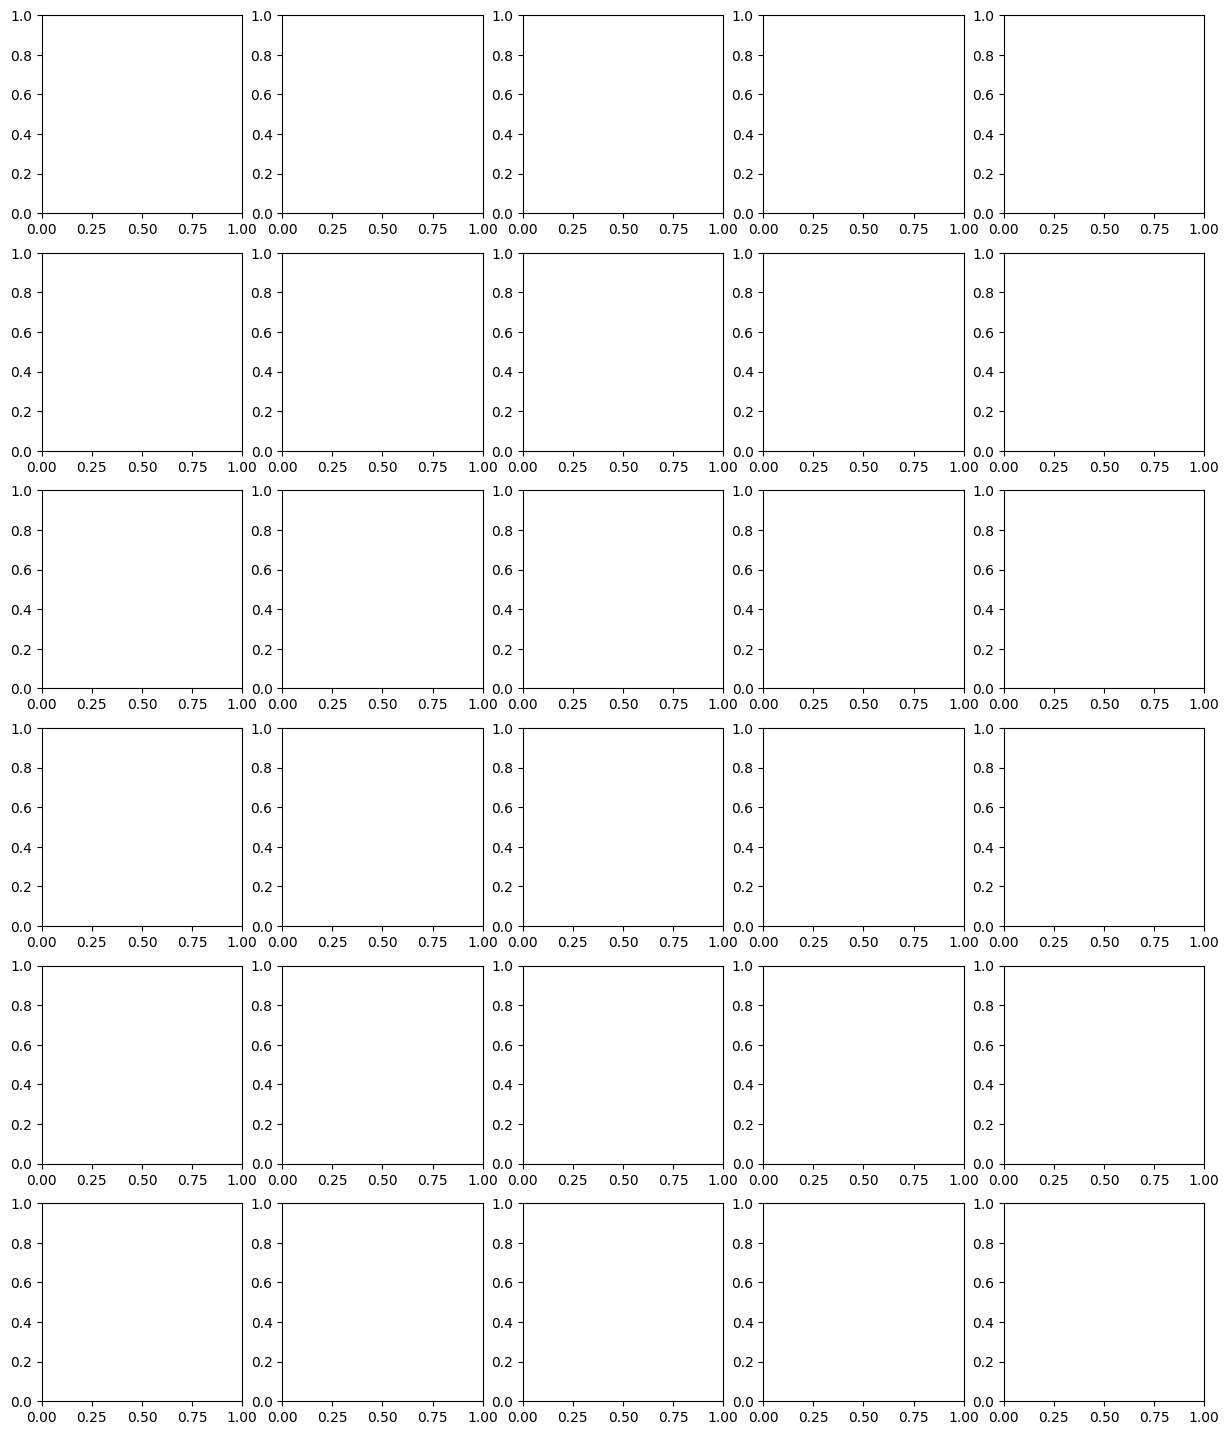

In [44]:
# 按image分组绘制PETH：每个neuron每个image的mean PETH和std
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

# 加载必要的数据
output_dir = '/home/ubuntu/Documents/jct/project/sorted/251205_kilosort'

if 'trial_peth_matrix_filtered' not in locals() or 'trial_image_info' not in locals():
    # 加载筛选后的矩阵和image信息
    filtered_output_path = os.path.join(output_dir, "trial_peth_matrix_filtered.npy")
    trial_image_info_path = os.path.join(output_dir, "trial_image_info.npy")
    
    trial_peth_matrix_filtered = np.load(filtered_output_path)
    trial_image_info = np.load(trial_image_info_path, allow_pickle=True)
    
    print(f"已加载trial_peth_matrix_filtered: {trial_peth_matrix_filtered.shape}")
    print(f"已加载trial_image_info: {len(trial_image_info)} 个trials")


# 确保trial_image_info和rec_params的顺序一致
n_trials, n_filtered_neurons, n_time_bins = trial_peth_matrix_filtered.shape
print(f"\ntrial_peth_matrix_filtered形状: ({n_trials}, {n_filtered_neurons}, {n_time_bins})")

# 获取所有唯一的image
unique_images = sorted(rec_params['image'].unique())
n_images = len(unique_images)
print(f"\n唯一image数量: {n_images}")

# 加载responsive_neurons以获取neuron IDs
responsive_neurons_path = os.path.join(output_dir, "responsive_neurons.npy")
responsive_neurons = np.load(responsive_neurons_path)
print(f"有反应的neurons数量: {len(responsive_neurons)}")

# 加载time_bins信息（用于x轴）
time_bins_path = os.path.join(output_dir, "peth_time_bins.npy")
time_bins = np.load(time_bins_path)
# 提取中间50个bins对应的时间点
time_bins_filtered = time_bins[26:76]  # 26-75对应的bin边界
time_bins_center = (time_bins_filtered[:-1] + time_bins_filtered[1:]) / 2  # bin中心点

print(f"\n开始绘制PETH图...")
print(f"每个image一页，共{n_images}页")
print(f"每个image包含{n_filtered_neurons}个neurons的PETH")

# 创建PDF文件
peth_by_image_pdf_path = os.path.join(output_dir, "peth_by_image_all_neurons.pdf")

with PdfPages(peth_by_image_pdf_path) as pdf:
    for image_idx, image_id in enumerate(unique_images):
        print(f"  处理image {image_idx+1}/{n_images}: {image_id}")
        
        # 获取该image的所有trials
        image_trial_indices = rec_params[rec_params['image'] == image_id].index.values
        image_trial_indices = image_trial_indices[image_trial_indices < n_trials]  # 确保索引有效
        
        if len(image_trial_indices) == 0:
            print(f"    警告: image {image_id} 没有有效的trials")
            continue
        
        # 获取该image的PETH数据
        image_peth_data = trial_peth_matrix_filtered[image_trial_indices, :, :]  # (n_trials_for_image, n_neurons, 50)
        
        # 计算mean和std
        mean_peth = np.mean(image_peth_data, axis=0)  # (n_neurons, 50)
        std_peth = np.std(image_peth_data, axis=0)   # (n_neurons, 50)
        
        # 创建图形：每个neuron一个subplot
        n_cols = 5
        n_rows = int(np.ceil(n_filtered_neurons / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
        axes = axes.flatten() if n_filtered_neurons > 1 else [axes]
        
        # 为每个neuron绘制PETH
        for neuron_idx in range(n_filtered_neurons):
            ax = axes[neuron_idx]
            
            # 绘制mean PETH
            ax.plot(time_bins_center, mean_peth[neuron_idx, :], 
                   color='black', linewidth=2, label='Mean')
            
            # 填充std区域
            ax.fill_between(time_bins_center, 
                          mean_peth[neuron_idx, :] - std_peth[neuron_idx, :],
                          mean_peth[neuron_idx, :] + std_peth[neuron_idx, :],
                          color='lightgray', alpha=0.5, label='±1 SD')
            
            # 设置标题和标签
            neuron_id = responsive_neurons[neuron_idx]
            ax.set_title(f'Neuron {neuron_id}', fontsize=10)
            ax.set_xlabel('Time (ms)', fontsize=9)
            ax.set_ylabel('Normalized Firing Rate', fontsize=9)
            ax.grid(True, alpha=0.3)
            
            # 隐藏多余的subplot
            if neuron_idx == 0:
                ax.legend(fontsize=8)
        
        # 隐藏多余的subplot
        for idx in range(n_filtered_neurons, len(axes)):
            axes[idx].axis('off')
        
        # 设置总标题
        fig.suptitle(f'Image: {image_id}\nTrials: {len(image_trial_indices)}', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\n完成! PETH图已保存到: {peth_by_image_pdf_path}")
print(f"共 {n_images} 页，每页包含 {n_filtered_neurons} 个neurons的PETH")
